<a href="https://colab.research.google.com/github/Sooraj055/AI-ML/blob/main/assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
zip_path = "/content/archive (4).zip"

In [2]:
import zipfile
import os

zip_path = "/content/archive (4).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/dataset


In [3]:
from glob import glob

image_paths = glob("/content/dataset/**/*.png", recursive=True)
print("Total Images:", len(image_paths))

Total Images: 100


In [4]:
import os
import cv2
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob
from PIL import Image


In [5]:

zip_path = "/content/archive (4).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [6]:

extensions = ['*.jpg','*.jpeg','*.png','*.bmp']

image_paths = []

for ext in extensions:
    image_paths.extend(
        glob(os.path.join(extract_path,'**',ext), recursive=True)
    )

print("Total Images:", len(image_paths))

Total Images: 100


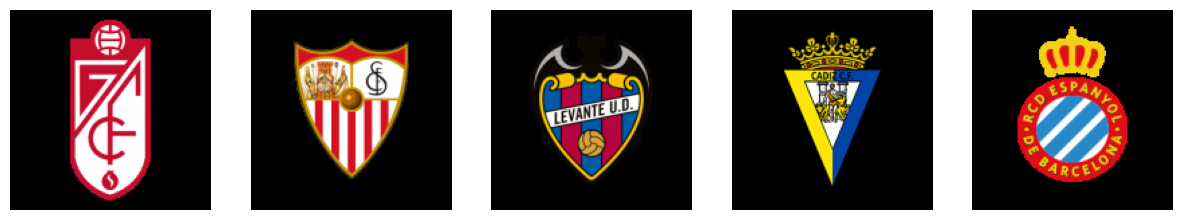

In [7]:

plt.figure(figsize=(15,5))

for i in range(5):
    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [8]:

data = []

for path in image_paths:
    img = cv2.imread(path)

    if img is not None:
        h,w,c = img.shape

        data.append([
            os.path.basename(path),
            h,
            w,
            c
        ])

df = pd.DataFrame(
    data,
    columns=["Image","Height","Width","Channels"]
)

df.head()

,Image,Height,Width,Channels
0,granada.png,150,150,3
1,sevilla.png,150,150,3
2,levante.png,150,150,3
3,cadiz.png,150,150,3
4,espanyol.png,150,150,3


In [9]:
df.to_csv("image_dimensions.csv", index=False)


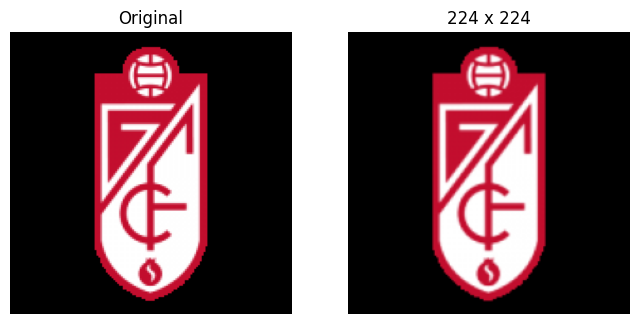

In [11]:
sample = cv2.imread(image_paths[0])

sample_rgb = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)

resized = cv2.resize(sample_rgb,(224,224))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(resized)
plt.title("224 x 224")
plt.axis("off")

plt.show()

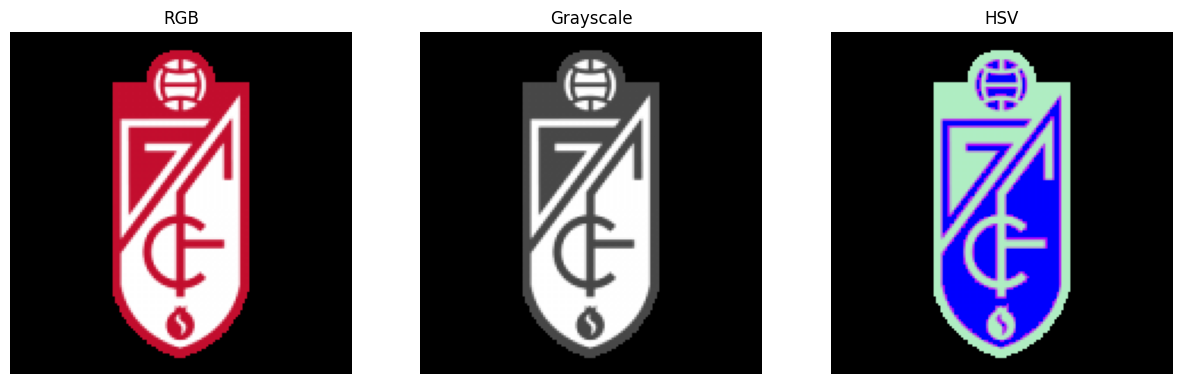

In [12]:
gray = cv2.cvtColor(sample_rgb, cv2.COLOR_RGB2GRAY)
hsv = cv2.cvtColor(sample_rgb, cv2.COLOR_RGB2HSV)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(sample_rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray,cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.show()


In [17]:
normalized = sample_rgb / 255.0

print("Before Normalization")
print("Min:", sample_rgb.min())
print("Max:", sample_rgb.max())

print("\nAfter Normalization")
print("Min:", normalized.min())
print("Max:", normalized.max())



Before Normalization
Min: 0
Max: 255

After Normalization
Min: 0.0
Max: 1.0


In [18]:
gaussian = cv2.GaussianBlur(
    sample_rgb,
    (5,5),
    0
)


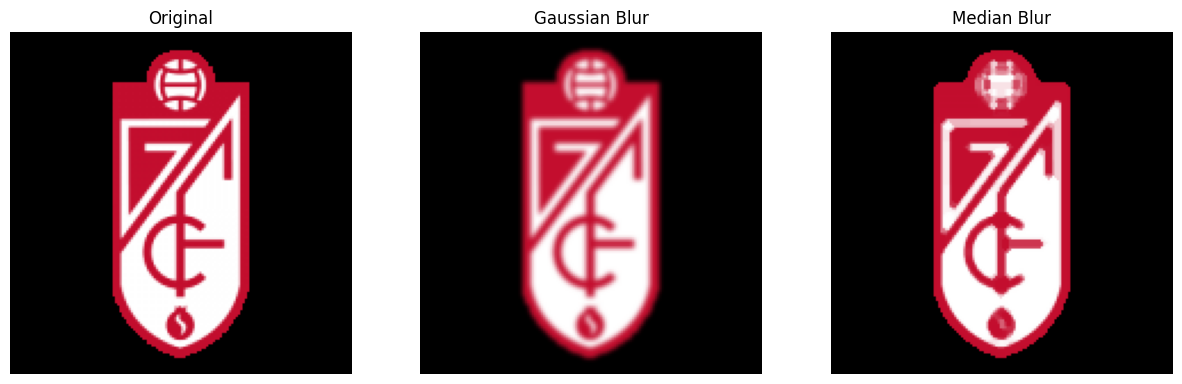

In [19]:
median = cv2.medianBlur(
    sample_rgb,
    5
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(sample_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gaussian)
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(median)
plt.title("Median Blur")
plt.axis("off")

plt.show()


In [20]:

gray_img = cv2.cvtColor(
    sample_rgb,
    cv2.COLOR_RGB2GRAY
)

hist_eq = cv2.equalizeHist(gray_img)

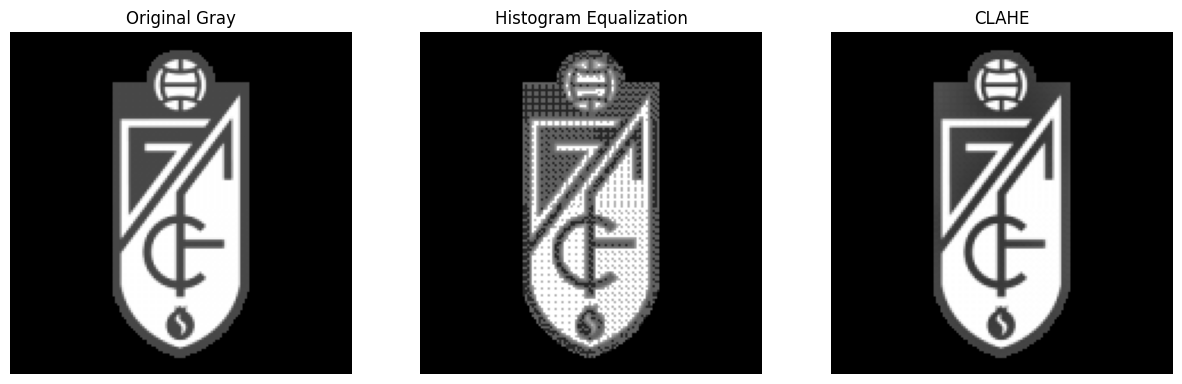

In [21]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

clahe_img = clahe.apply(gray_img)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray_img,cmap='gray')
plt.title("Original Gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(hist_eq,cmap='gray')
plt.title("Histogram Equalization")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(clahe_img,cmap='gray')
plt.title("CLAHE")
plt.axis("off")

plt.show()

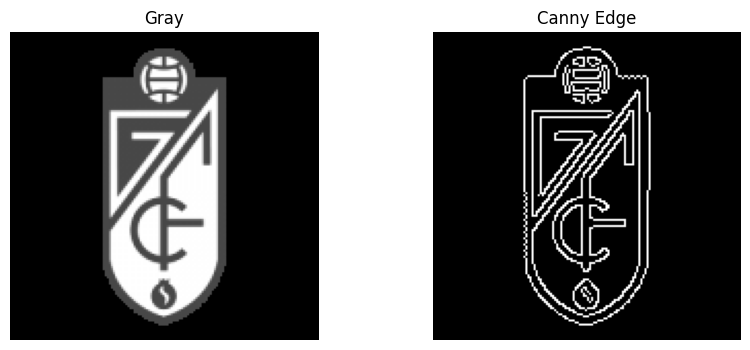

In [22]:

edges = cv2.Canny(
    gray_img,
    100,
    200
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray_img,cmap='gray')
plt.title("Gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges,cmap='gray')
plt.title("Canny Edge")
plt.axis("off")

plt.show()


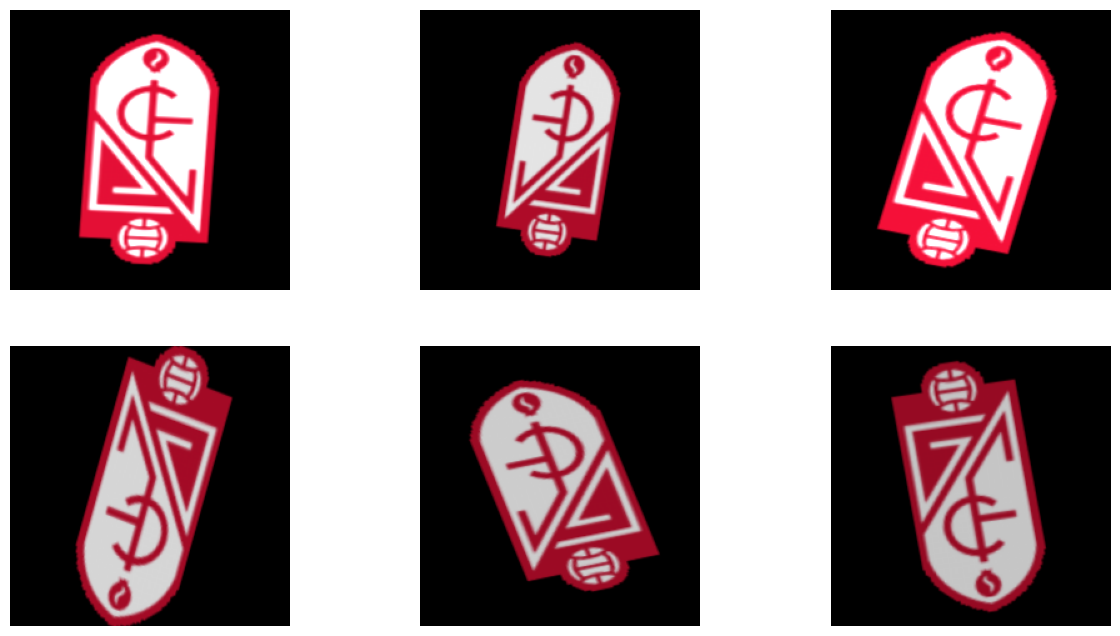

In [23]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.7,1.3]
)

img = cv2.resize(sample_rgb,(224,224))
img = np.expand_dims(img,axis=0)

aug_iter = datagen.flow(img,batch_size=1)

plt.figure(figsize=(15,8))

for i in range(6):

    batch = next(aug_iter)

    plt.subplot(2,3,i+1)
    plt.imshow(batch[0].astype(np.uint8))
    plt.axis("off")

plt.show()

In [24]:

def preprocess_image(image_path):

    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (224,224)
    )

    img = img / 255.0

    img = cv2.GaussianBlur(
        img,
        (5,5),
        0
    )

    return img

processed = preprocess_image(
    image_paths[0]
)

print("Processed Shape:", processed.shape)

Processed Shape: (224, 224, 3)
